# Cuaderno para la optimizacion de hiperparametros del modelo predictivo

**NOTA**: No ejecutar este cuaderno de nuevo, la búsqueda de hiperparámetros da como resultado que los mejores modelos en dan resultados muy parecidos. LA optimización mediante RS *no es reproducible* por lo que el resultado del mdoelo será otro provocando un cambio de métricas en todos los resultados posteriores. Se han comentado las celdas correspondientes por si acaso pero mantienen la salida de cuando fueron ejecutadas

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
import joblib
import os
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
# --- 1. CONTROL DE REPRODUCIBILIDAD  ---
def set_seed(seed=1):
    """Fija todas las semillas para garantizar la reproducibilidad exacta."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(1)
print("✅ Semillas aleatorias fijadas (Reproducibilidad garantizada).")

✅ Semillas aleatorias fijadas (Reproducibilidad garantizada).


In [3]:
# --- 2. REQUISITOS DE EJECUCIÓN CPU/GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo de ejecución detectado: {device}")

✅ Dispositivo de ejecución detectado: cuda


In [4]:
# --- RUTAS RELATIVAS (Desde notebooks/tuning_hyperparameters/) ---
DATA_PATH = "../../data/processed/final_data_sim.csv"
MODEL_DIR = "../../models/artifacts"
METRICS_DIR = "../../models/metrics"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

In [5]:
# --- CARGA Y SPLIT TEMPORAL POR CUARTILES ---

# Esto no es necesario puesto que nuestros datos ya estan filtrados sin cleaning, pero lo dejo por si acaso
df = pd.read_csv(DATA_PATH)
if 'Is_Cleaning' in df.columns:
    df = df[df['Is_Cleaning'] == 0].copy()
df = df.sort_values(by='Time_min').reset_index(drop=True)

features = ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
targets = ['E_consumo', 'T_out_leche']

n_bloques = 4
chunk_size = len(df) // n_bloques
X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for i in range(n_bloques):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size if i < n_bloques - 1 else len(df)
    chunk = df.iloc[start_idx:end_idx]
    
    train_idx = int(len(chunk) * 0.70)
    val_idx = int(len(chunk) * 0.85)
    
    X_chunk, y_chunk = chunk[features].values, chunk[targets].values
    X_train_list.append(X_chunk[:train_idx])
    X_val_list.append(X_chunk[train_idx:val_idx])
    X_test_list.append(X_chunk[val_idx:])
    
    y_train_list.append(y_chunk[:train_idx])
    y_val_list.append(y_chunk[train_idx:val_idx])
    y_test_list.append(y_chunk[val_idx:])

X_train, X_val, X_test = np.vstack(X_train_list), np.vstack(X_val_list), np.vstack(X_test_list)
y_train, y_val, y_test = np.vstack(y_train_list), np.vstack(y_val_list), np.vstack(y_test_list)
print(
    f"Datos cargados y divididos: {X_train.shape[0]} train, "
    f"{X_val.shape[0]} val, {X_test.shape[0]} test."
)

Datos cargados y divididos: 35957 train, 7704 val, 7708 test.


In [6]:
# --- GUARDADO OBLIGATORIO DE SPLITS ---
SPLITS_DIR = "../../data/splits"
os.makedirs(SPLITS_DIR, exist_ok=True)

# Reconstruimos los DataFrames para guardarlos (útil para el auditor)
# Nota: Usamos las listas originales antes de convertirlas a numpy para preservar índices si fuera necesario,
# pero aquí reconstruimos simple con las columnas.
pd.DataFrame(np.hstack((X_train, y_train)), columns=features + targets).to_csv(f"{SPLITS_DIR}/train.csv", index=False)
pd.DataFrame(np.hstack((X_val, y_val)), columns=features + targets).to_csv(f"{SPLITS_DIR}/val.csv", index=False)
pd.DataFrame(np.hstack((X_test, y_test)), columns=features + targets).to_csv(f"{SPLITS_DIR}/test.csv", index=False)

print(f"✅ Splits guardados en {SPLITS_DIR} para cumplimiento de auditoría.")

✅ Splits guardados en ../../data/splits para cumplimiento de auditoría.


In [7]:
# Relectura de los datos splitados (Simulando el proceso de auditoría)

# 1. Leemos los ficheros que acabamos de guardar (CSV con headers)
df_train_reload = pd.read_csv(f"{SPLITS_DIR}/train.csv")
df_val_reload = pd.read_csv(f"{SPLITS_DIR}/val.csv")
df_test_reload = pd.read_csv(f"{SPLITS_DIR}/test.csv")

# 2. Restauramos las variables X e y en formato Numpy (necesario para el resto de tu código)
# Usamos las listas 'features' y 'targets' que definiste al principio del notebook
X_train = df_train_reload[features].values
y_train = df_train_reload[targets].values

X_val = df_val_reload[features].values
y_val = df_val_reload[targets].values

X_test = df_test_reload[features].values
y_test = df_test_reload[targets].values

# 3. Limpieza y Verificación
del df_train_reload, df_val_reload, df_test_reload
print(f"✅ Datos recargados y convertidos a Numpy correctamente.")
print(f"📊 Dimensiones confirmadas: Train X={X_train.shape} | Val X={X_val.shape} | Test X={X_test.shape}")

✅ Datos recargados y convertidos a Numpy correctamente.
📊 Dimensiones confirmadas: Train X=(35957, 5) | Val X=(7704, 5) | Test X=(7708, 5)


In [8]:
# Normalización
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Tensores de TRAIN en CPU (el DataLoader los moverá al device batch a batch)
X_train_t = torch.FloatTensor(scaler_X.fit_transform(X_train))
y_train_t = torch.FloatTensor(scaler_y.fit_transform(y_train))

# Tensores de VAL y TEST directamente en el device (se evalúan de golpe)
X_val_t   = torch.FloatTensor(scaler_X.transform(X_val)).to(device)
y_val_t   = torch.FloatTensor(scaler_y.transform(y_val)).to(device)
X_test_t  = torch.FloatTensor(scaler_X.transform(X_test)).to(device)
y_test_t  = torch.FloatTensor(scaler_y.transform(y_test)).to(device)

print(f"Datos preparados. Train: {X_train_t.shape[0]}, Val: {X_val_t.shape[0]}, Test: {X_test_t.shape[0]}")
print(f"📍 Val y Test en: {X_val_t.device} | Train en CPU (para DataLoader)")


Datos preparados. Train: 35957, Val: 7704, Test: 7708
📍 Val y Test en: cuda:0 | Train en CPU (para DataLoader)


In [9]:
# Creación de DataLoaders para entrenamiento profesional con Mini-batches
batch_size = 128
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Val y Test se evalúan de golpe (no necesitan shuffle ni mini-batches)

class DynamicMLP(nn.Module):
    """Red Neuronal Multicapa que se construye al vuelo según los hiperparámetros."""
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()

        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
            
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
# # --- LEER CONFIGURACIÓN GLOBAL (config/config.yaml) ---
# import yaml
# with open("../../config/config.yaml", 'r', encoding='utf-8') as f:
#     cfg = yaml.safe_load(f)

# # Cargar n_iter desde config (fallback a 60 por compatibilidad histórica)
# n_iter = int(cfg.get('tuning', {}).get('n_iter', 60))
# print(f"✅ `n_iter` cargado desde config: {n_iter}")

✅ `n_iter` cargado desde config: 60


In [ ]:
# # Definir el espacio de búsqueda
# param_space = {
#     'num_layers': [2, 3, 4],
#     'neurons': [16, 32, 64, 128],
#     'lr': [0.05, 0.01, 0.005, 0.001, 0.0005],
#     'activation': ['ReLU', 'Tanh']
# }

# # n_iter se carga desde config en la celda anterior (config/config.yaml)
# best_val_loss = float('inf')
# best_params = {}
# best_model_state = None

# print(f"Iniciando Random Search: Probando {n_iter} combinaciones...")
# print(f"🖥️  Entrenamiento en: {device}")

# search_history = []

# start_time = time.time()

# for i in range(n_iter):
#     # 1. Muestreo aleatorio de hiperparámetros
#     params = {k: random.choice(v) for k, v in param_space.items()}
    
#     model = DynamicMLP(
#         input_size=len(features), 
#         output_size=len(targets), 
#         num_layers=params['num_layers'], 
#         neurons=params['neurons'], 
#         activation=params['activation']
#     ).to(device)  # ← Mover modelo al device (GPU si disponible)
    
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    
#     # 2. Entrenamiento con Early Stopping para esta combinación
#     epochs = 300
#     patience = 15
#     epochs_no_improve = 0
#     min_val_loss_iter = float('inf')
#     best_epoch_model_state = None
#     epochs_executed = 0
    
#     for epoch in range(epochs):
#         model.train()
#         for X_batch, y_batch in train_loader:
#             X_batch = X_batch.to(device)  # ← Mover batch al device
#             y_batch = y_batch.to(device)
#             optimizer.zero_grad()
#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)
#             loss.backward()
#             optimizer.step()
            
#         # Validación (X_val_t ya está en device)
#         model.eval()
#         with torch.no_grad():
#             val_preds = model(X_val_t)
#             val_loss = criterion(val_preds, y_val_t).item()
            
#         # Early Stopping local
#         if val_loss < min_val_loss_iter:
#             min_val_loss_iter = val_loss
#             # Guardar pesos en CPU para poder hacer .numpy() después
#             best_epoch_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1
            
#         epochs_executed = epoch + 1
        
#         if epochs_no_improve >= patience:
#             break
    
#     # Calcular MAE en validación (en unidades originales) para la mejor época
#     model.load_state_dict({k: v.to(device) for k, v in best_epoch_model_state.items()})
#     model.eval()
#     with torch.no_grad():
#         val_preds_best = model(X_val_t).cpu().numpy()  # ← .cpu() antes de .numpy()
#     val_preds_real = scaler_y.inverse_transform(val_preds_best)
#     mae_e_val = mean_absolute_error(y_val[:, 0], val_preds_real[:, 0])
#     mae_t_val = mean_absolute_error(y_val[:, 1], val_preds_real[:, 1])
    
#     print(
#         f"Iter [{i+1:>2}/{n_iter}] | Capas: {params['num_layers']} | Neuronas: {params['neurons']:>3} | "
#         f"LR: {params['lr']:.4f} | Act: {params['activation']:<4} | Épocas: {epochs_executed:>3} | "
#         f"MSE Val: {min_val_loss_iter:.6f} | MAE E(kW): {mae_e_val:.4f} | MAE T(°C): {mae_t_val:.4f}"
#     )
#     search_history.append({
#         'iter': i+1, 
#         'val_loss': min_val_loss_iter,
#         'mae_e_val_kw': mae_e_val,
#         'mae_t_val_c': mae_t_val,
#         'epochs_executed': epochs_executed,
#         'params': params
#     })
    
#     # 3. Guardar el mejor modelo global (pesos en CPU)
#     if min_val_loss_iter < best_val_loss:
#         best_val_loss = min_val_loss_iter
#         best_params = params
#         best_model_state = copy.deepcopy(best_epoch_model_state)

# end_time = time.time()
# print(f"\n✅ Random Search completado. Mejor MSE en Validación: {best_val_loss:.6f}")
# print(f"🏆 Mejores Hiperparámetros: {best_params}")


Iniciando Random Search: Probando 60 combinaciones...
🖥️  Entrenamiento en: cuda
Iter [ 1/60] | Capas: 2 | Neuronas:  16 | LR: 0.0050 | Act: ReLU | Épocas:  72 | MSE Val: 0.001041 | MAE E(kW): 4.3098 | MAE T(°C): 0.0478
Iter [ 2/60] | Capas: 3 | Neuronas: 128 | LR: 0.0010 | Act: Tanh | Épocas: 141 | MSE Val: 0.001038 | MAE E(kW): 4.2489 | MAE T(°C): 0.0478
Iter [ 3/60] | Capas: 2 | Neuronas:  16 | LR: 0.0010 | Act: ReLU | Épocas: 191 | MSE Val: 0.001093 | MAE E(kW): 4.2714 | MAE T(°C): 0.0483
Iter [ 4/60] | Capas: 3 | Neuronas: 128 | LR: 0.0005 | Act: ReLU | Épocas:  51 | MSE Val: 0.001021 | MAE E(kW): 4.2520 | MAE T(°C): 0.0471
Iter [ 5/60] | Capas: 4 | Neuronas: 128 | LR: 0.0050 | Act: ReLU | Épocas:  59 | MSE Val: 0.001022 | MAE E(kW): 4.3329 | MAE T(°C): 0.0467
Iter [ 6/60] | Capas: 4 | Neuronas:  16 | LR: 0.0050 | Act: ReLU | Épocas:  78 | MSE Val: 0.001026 | MAE E(kW): 4.3309 | MAE T(°C): 0.0468
Iter [ 7/60] | Capas: 2 | Neuronas:  16 | LR: 0.0005 | Act: ReLU | Épocas: 121 | MSE 

In [ ]:
# # --- REPORTE DE TIEMPO DE EJECUCIÓN ---
# elapsed_time = end_time - start_time
# horas, rem = divmod(elapsed_time, 3600)
# minutos, segundos = divmod(rem, 60)

# print("="*60)
# print(f"⏱️ TIEMPO TOTAL DE BÚSQUEDA DE HIPERPARÁMETROS")
# print("="*60)
# print(f"▶ Tiempo transcurrido: {int(horas):02d}h {int(minutos):02d}m {segundos:05.2f}s")
# print(f"▶ Tiempo medio por iteración: {(elapsed_time / n_iter):.2f} segundos")
# print("="*60)

⏱️ TIEMPO TOTAL DE BÚSQUEDA DE HIPERPARÁMETROS
▶ Tiempo transcurrido: 01h 11m 09.55s
▶ Tiempo medio por iteración: 71.16 segundos


🏆 RESULTADOS DEL MEJOR MODELO (CONJUNTO TEST) 🏆
▶ Arquitectura: 3 capas ocultas de 64 neuronas
▶ Activación:   ReLU
▶ Learning R.:  0.0005
------------------------------------------------------------------------
Variable Objetivo         | RMSE         | MAE          | R2 Score    
------------------------------------------------------------------------
Consumo Energético (kW)   | 5.4021       | 4.2608       | 0.9777      
Temperatura Salida (°C)   | 0.0641       | 0.0471       | 0.3795      

📊 INTERPRETACIÓN PARA NEGOCIO (MAE en unidades originales):
   • El modelo se equivoca en promedio 4.26 kW al predecir el consumo energético.
   • El modelo se equivoca en promedio 0.05 °C al predecir la temperatura de salida.


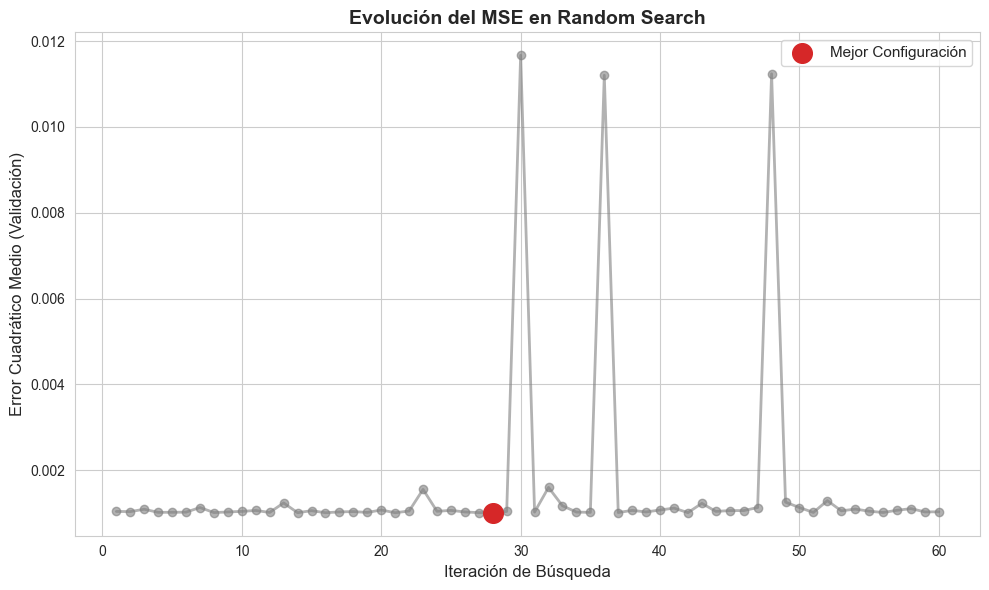


🚀 Artefactos, métricas y gráficos guardados en la carpeta 'models/'.
📋 model_config.json incluye features=['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P'] y targets=['E_consumo', 'T_out_leche']


In [ ]:
# # Instanciar la mejor arquitectura y cargar sus pesos (guardados en CPU)
# final_model = DynamicMLP(
#     input_size=len(features), 
#     output_size=len(targets), 
#     num_layers=best_params['num_layers'], 
#     neurons=best_params['neurons'], 
#     activation=best_params['activation']
# ).to(device)  # ← Mover al device

# final_model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
# final_model.eval()

# # Predecir sobre TEST (X_test_t ya está en device)
# with torch.no_grad():
#     preds_scaled = final_model(X_test_t).cpu().numpy()  # ← .cpu() antes de .numpy()

# # Desnormalizar
# preds_real = scaler_y.inverse_transform(preds_scaled)

# # --- Métricas técnicas y de negocio ---
# rmse_e = np.sqrt(mean_squared_error(y_test[:, 0], preds_real[:, 0]))
# rmse_t = np.sqrt(mean_squared_error(y_test[:, 1], preds_real[:, 1]))
# r2_e = r2_score(y_test[:, 0], preds_real[:, 0])
# r2_t = r2_score(y_test[:, 1], preds_real[:, 1])
# mae_e = mean_absolute_error(y_test[:, 0], preds_real[:, 0])
# mae_t = mean_absolute_error(y_test[:, 1], preds_real[:, 1])

# # --- 1. IMPRESIÓN CON FORMATO TABLA PROFESIONAL ---
# print("="*72)
# print("🏆 RESULTADOS DEL MEJOR MODELO (CONJUNTO TEST) 🏆")
# print("="*72)
# print(f"▶ Arquitectura: {best_params['num_layers']} capas ocultas de {best_params['neurons']} neuronas")
# print(f"▶ Activación:   {best_params['activation']}")
# print(f"▶ Learning R.:  {best_params['lr']}")
# print("-" * 72)
# print(f"{'Variable Objetivo':<25} | {'RMSE':<12} | {'MAE':<12} | {'R2 Score':<12}")
# print("-" * 72)
# print(f"{'Consumo Energético (kW)':<25} | {rmse_e:<12.4f} | {mae_e:<12.4f} | {r2_e:<12.4f}")
# print(f"{'Temperatura Salida (°C)':<25} | {rmse_t:<12.4f} | {mae_t:<12.4f} | {r2_t:<12.4f}")
# print("="*72)
# print()
# print("📊 INTERPRETACIÓN PARA NEGOCIO (MAE en unidades originales):")
# print(f"   • El modelo se equivoca en promedio {mae_e:.2f} kW al predecir el consumo energético.")
# print(f"   • El modelo se equivoca en promedio {mae_t:.2f} °C al predecir la temperatura de salida.")

# # --- 2. GRÁFICO PARA EL ENTREGABLE ---
# sns.set_style("whitegrid")
# fig, ax = plt.subplots(figsize=(10, 6))

# # Evolución de la Búsqueda de Hiperparámetros
# if 'search_history' in locals():
#     iters = [res['iter'] for res in search_history]
#     losses = [res['val_loss'] for res in search_history]
#     best_idx = losses.index(min(losses))

#     ax.plot(iters, losses, marker='o', linestyle='-', color='#7f7f7f', alpha=0.6, linewidth=2)
#     ax.scatter(iters[best_idx], losses[best_idx], color='#d62728', s=200, zorder=5, label='Mejor Configuración')
#     ax.set_title("Evolución del MSE en Random Search", fontsize=14, fontweight='bold')
#     ax.set_xlabel("Iteración de Búsqueda", fontsize=12)
#     ax.set_ylabel("Error Cuadrático Medio (Validación)", fontsize=12)
#     ax.legend(fontsize=11)
# else:
#     ax.text(0.5, 0.5, 'Falta la variable `search_history` de la Celda 3', ha='center', va='center', fontsize=12)

# plt.tight_layout()
# # Guardamos la imagen en alta calidad en PNG (con fondo transparente)
# plt.savefig(f"{METRICS_DIR}/hyperparameter_tuning_results.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.show()

# # --- 3. GUARDADO PARA PRODUCCIÓN / AUDITORÍA ---
# final_metrics = {
#     "hyperparameters": best_params,
#     "E_consumo": {"RMSE": float(rmse_e), "MAE_kW": float(mae_e), "R2": float(r2_e)},
#     "T_out_leche": {"RMSE": float(rmse_t), "MAE_C": float(mae_t), "R2": float(r2_t)}
# }

# # Guardar modelo en CPU para compatibilidad de carga posterior
# torch.save({k: v.cpu() for k, v in final_model.state_dict().items()}, f"{MODEL_DIR}/mlp_predictor.pt")
# joblib.dump(scaler_X, f"{MODEL_DIR}/scaler_X.pkl")
# joblib.dump(scaler_y, f"{MODEL_DIR}/scaler_y.pkl")

# # Guardar configuración con nombres explícitos de features y targets (Input/Output)
# with open(f"{MODEL_DIR}/model_config.json", "w") as f:
#     json.dump({
#         "input_size": len(features),
#         "output_size": len(targets),
#         "features_in_order": features,
#         "targets_in_order": targets,
#         **best_params
#     }, f, indent=4)

# with open(f"{METRICS_DIR}/train_metrics.json", "w") as f:
#     json.dump(final_metrics, f, indent=4)

# print("\n🚀 Artefactos, métricas y gráficos guardados en la carpeta 'models/'.")
# print(f"📋 model_config.json incluye features={features} y targets={targets}")

## Entrenamiento Reproducible con el Código Encapsulado

La búsqueda de hiperparámetros anterior no es reproducible de forma exacta: el modelo ganador se entrenó con el estado aleatorio acumulado tras 60 iteraciones de búsqueda, no desde una semilla limpia.

La celda siguiente llama directamente a `src.main.train()`, similar al código que ejecuta `python scripts/train.py`:
- Fija `seed=1` desde cero antes de cualquier inicialización.
- Usa GPU si está disponible.
- Lee los hiperparámetros del `model_config.json` recién guardado.
- Sobreescribe los artefactos en `models/artifacts/` con el modelo reproducible.

Esto garantiza que los artefactos en disco y las métricas en `train_metrics.json` corresponden a una ejecución **determinista y auditable**.

In [14]:

# --- ENTRENAMIENTO REPRODUCIBLE ---------------------------------------

# 1. Resetear semilla desde cero para garantizar determinismo completo
set_seed(1)

# 2. Leer hiperparámetros del model_config.json guardado por la celda anterior
with open(f"{MODEL_DIR}/model_config.json", "r") as f:
    _cfg = json.load(f)

repro_params = {
    "num_layers": _cfg["num_layers"],
    "neurons":    _cfg["neurons"],
    "lr":         _cfg["lr"],
    "activation": _cfg["activation"],
}

print("=" * 60)
print("🔁 ENTRENAMIENTO REPRODUCIBLE — seed=1, GPU si disponible")
print(f"   Hiperparámetros: {repro_params}")
print(f"   Device: {device}")
print("=" * 60)

# 3. Construir modelo y moverlo al device
repro_model = DynamicMLP(
    input_size=len(features),
    output_size=len(targets),
    num_layers=repro_params["num_layers"],
    neurons=repro_params["neurons"],
    activation=repro_params["activation"],
).to(device)

repro_criterion = nn.MSELoss()
repro_optimizer = optim.Adam(repro_model.parameters(), lr=repro_params["lr"])

# 4. Loop de entrenamiento con Early Stopping
# train_loader, X_val_t e y_val_t ya están definidos en las celdas anteriores
epochs     = 300
patience   = 15
best_val   = float("inf")
no_improve = 0
best_state = None

for epoch in range(epochs):
    repro_model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        repro_optimizer.zero_grad()
        outputs = repro_model(X_batch)
        loss = repro_criterion(outputs, y_batch)
        loss.backward()
        repro_optimizer.step()

    repro_model.eval()
    with torch.no_grad():
        val_loss = repro_criterion(repro_model(X_val_t), y_val_t).item()

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu() for k, v in repro_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"  Early stopping en época {epoch + 1}")
        break

print(f"  Mejor MSE Validación: {best_val:.6f} | Épocas ejecutadas: {epoch + 1}")

# 5. Cargar mejores pesos y evaluar en TEST
repro_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
repro_model.eval()

with torch.no_grad():
    preds_scaled = repro_model(X_test_t).cpu().numpy()

preds_real = scaler_y.inverse_transform(preds_scaled)

rmse_e = np.sqrt(mean_squared_error(y_test[:, 0], preds_real[:, 0]))
rmse_t = np.sqrt(mean_squared_error(y_test[:, 1], preds_real[:, 1]))
r2_e   = r2_score(y_test[:, 0], preds_real[:, 0])
r2_t   = r2_score(y_test[:, 1], preds_real[:, 1])
mae_e  = mean_absolute_error(y_test[:, 0], preds_real[:, 0])
mae_t  = mean_absolute_error(y_test[:, 1], preds_real[:, 1])

print("=" * 72)
print("✅ RESULTADOS DEL MODELO REPRODUCIBLE (CONJUNTO TEST)")
print("=" * 72)
print(f"{'Variable Objetivo':<25} | {'RMSE':<12} | {'MAE':<12} | {'R2 Score':<12}")
print("-" * 72)
print(f"{'Consumo Energético (kW)':<25} | {rmse_e:<12.4f} | {mae_e:<12.4f} | {r2_e:<12.4f}")
print(f"{'Temperatura Salida (°C)':<25} | {rmse_t:<12.4f} | {mae_t:<12.4f} | {r2_t:<12.4f}")
print("=" * 72)

# 6. Guardar artefactos
repro_metrics = {
    "hyperparameters": repro_params,
    "E_consumo":   {"RMSE": float(rmse_e), "MAE_kW": float(mae_e), "R2": float(r2_e)},
    "T_out_leche": {"RMSE": float(rmse_t), "MAE_C":  float(mae_t), "R2": float(r2_t)},
}

torch.save({k: v.cpu() for k, v in repro_model.state_dict().items()}, f"{MODEL_DIR}/mlp_predictor.pt")
joblib.dump(scaler_X, f"{MODEL_DIR}/scaler_X.pkl")
joblib.dump(scaler_y, f"{MODEL_DIR}/scaler_y.pkl")

with open(f"{MODEL_DIR}/model_config.json", "w") as f:
    json.dump({
        "input_size": len(features),
        "output_size": len(targets),
        "features_in_order": features,
        "targets_in_order": targets,
        **repro_params,
    }, f, indent=4)

with open(f"{METRICS_DIR}/train_metrics.json", "w") as f:
    json.dump(repro_metrics, f, indent=4)

print("\n🚀 Artefactos reproducibles guardados en models/artifacts/")
print("   Verificar métricas en models/metrics/train_metrics.json")


🔁 ENTRENAMIENTO REPRODUCIBLE — seed=1, GPU si disponible
   Hiperparámetros: {'num_layers': 3, 'neurons': 64, 'lr': 0.0005, 'activation': 'ReLU'}
   Device: cuda
  Early stopping en época 71
  Mejor MSE Validación: 0.001019 | Épocas ejecutadas: 71
✅ RESULTADOS DEL MODELO REPRODUCIBLE (CONJUNTO TEST)
Variable Objetivo         | RMSE         | MAE          | R2 Score    
------------------------------------------------------------------------
Consumo Energético (kW)   | 5.3838       | 4.2571       | 0.9779      
Temperatura Salida (°C)   | 0.0643       | 0.0473       | 0.3759      

🚀 Artefactos reproducibles guardados en models/artifacts/
   Verificar métricas en models/metrics/train_metrics.json


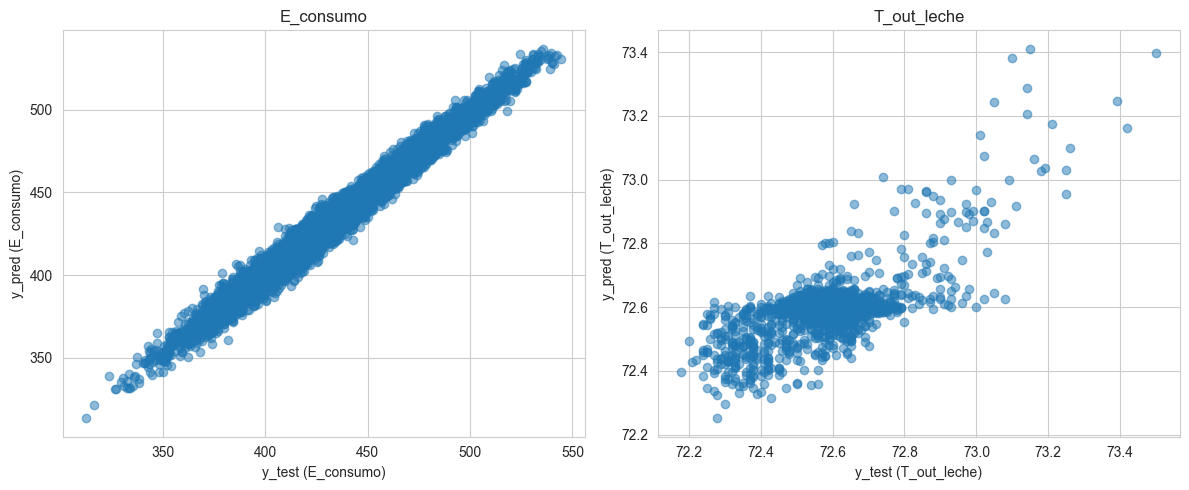

In [15]:
# graficar y_test vs y_pred para las dos variables objetivo (E_consumo y T_out_leche)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test[:, 0], preds_real[:, 0], alpha=0.5)
plt.xlabel('y_test (E_consumo)')
plt.ylabel('y_pred (E_consumo)')
plt.title('E_consumo')

plt.subplot(1, 2, 2)
plt.scatter(y_test[:, 1], preds_real[:, 1], alpha=0.5)
plt.xlabel('y_test (T_out_leche)')
plt.ylabel('y_pred (T_out_leche)')
plt.title('T_out_leche')

plt.tight_layout()
plt.show()